In [ ]:
# ──────────────────────────────────────────────────────────────
# Headers are in the code because they look nice
# "If my commit messages don't have emojis, how would you know how I feel?"
# - ProgrammersAreAlsoHuman, '0.1x engineers'
# ──────────────────────────────────────────────────────────────

"""
This code trains several models to perform a 3SUM task generated
by https://github.com/JacobPfau/fillerTokens/tree/master, comparing
model training curves, attention maps, and test set performance in
order to highlight the role of filler tokens.


I plan to use these training runs:
    1) CoT as filler (filler unmasked)
    2) Dots as filler (filler masked out)
    3) Low entropy tokens as filler (filler masked out)
    4) High entropy tokens as filler (filler masked out)
    5) Direct-to-answer

This allows for
    1) A high-quality gold standard for the model, direct-to-answer.  Not very related to my experiment but a super-baseline.
    2) Progressively more difficult tasks to pull out some sort of linear relationship (heavily relies on the assumption that I've picked tokens which are linear along some x axis, but these *were* calculated via the entropix repo as progressively more-difficult-to-predict tokens.  Need to formalize this more but for now not worth the time).  Keep the experiment simple as there are so many possible experiments.


Outline of data pipeline for clarity:
1) We generate three kinds of samples, direct, CoT and punct:
    533 569 530 814 A False
    371 578 006 519 P 1- 4 0- 7 3- 7- 4- 4 5- 6 A True
    873 545 827 245 P . . . . . . . . . . . . . A False
    # Note that this is prompt followed by answer in the same string
    # Answers are one word long (True/False), so
      future [-1], len(prompt)-1, are referring to this
2) Turn that into a HF dataset which has two columns:
    a) input_ids: tokenized full prompts
    b) labels: same except -100-masked everywhere but answer
"""


In [1]:
# ──────────────────────────────────────────────────────────────
# Installs
# ──────────────────────────────────────────────────────────────
# Try/except to avoid repeated install; not sure of a better way
try:
    import bitsandbytes as bnb
except:
    # This takes a while but at the moment I think this is the minimal necessary to get all the stuff to work together:
    !pip uninstall -y torch torchvision torchaudio -q
    !pip install --index-url https://download.pytorch.org/whl/cu121 \
        torch==2.3.0 torchvision torchaudio
    !pip install flash-attn==2.7.4.post1 --no-build-isolation
    !pip install -U bitsandbytes==0.45.5
    !pip install -U "fsspec==2025.3.2"
    !pip install -U transformers accelerate peft datasets tqdm


Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 781.0/781.0 MB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 126.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 104.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 99.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 52.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 115.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 19.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 13.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 20.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/1

In [2]:
# ──────────────────────────────────────────────────────────────
# Imports
# ──────────────────────────────────────────────────────────────
import datetime as dt
import itertools
import json
import os
import tempfile
import pathlib
import shutil
import re
import textwrap
import subprocess
import shlex
import warnings
from pathlib import Path
from glob import glob
from functools import partial
from typing import Final
from types import SimpleNamespace as ns
from collections import Counter

import numpy as np
import pandas as pd
import polars as pl
import torch
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from datasets import load_dataset, load_from_disk
from google.colab import drive
from huggingface_hub import notebook_login
from peft import LoraConfig, get_peft_model, PeftModel
from tqdm.auto import tqdm
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    TrainerCallback
)
from sklearn.metrics import accuracy_score


In [155]:
# ──────────────────────────────────────────────────────────────
# Global variables and namespace for the run
# ──────────────────────────────────────────────────────────────
# Run namespace
presets = {
    'cot': ns(
        runtype='cot',
        save_tag=None,
        filler_tok=None
    ),
    'direct': ns(
        runtype='direct',
        save_tag=None,
        filler_tok=None
    ),
    'filler_space-dot': ns(
        runtype='filler',
        save_tag='space-dot',
        filler_tok=' .'
    ),
    'filler_Peter': ns(
        runtype='filler',
        save_tag='Peter',
        filler_tok='Peter'
    ),
    'filler_ctrl14': ns(
        runtype='filler',
        save_tag='ctrl14',
        filler_tok=b'\x14'.decode('latin-1')
    ),
    'filler_dot': ns(
        runtype='filler',
        save_tag='dot',
        filler_tok='.'
    ),
    'filler_space-comma': ns(
        runtype='filler',
        save_tag='space-comma',
        filler_tok=' ,'
    ),
    'filler_space-neu': ns(
        runtype='filler',
        save_tag='space-neu',
        filler_tok=' neu'
    ),
    'filler_space-big': ns(
        runtype='filler',
        save_tag='space-big',
        filler_tok=' big'
    )
}
cfg = presets['filler_space-dot']
cfg.lora_target = 'attn'

# Core paths
BASE_DIR = "/content/drive/MyDrive/Colab_Files/repurposed_tokens"
DATA_DIR = os.path.join(BASE_DIR, 'data')
MODEL_ID = "meta-llama/Llama-3.2-1B"  # or 3-8B
MODEL_NAME = MODEL_ID.split('/')[-1]
tag = f"/{cfg.save_tag}" if cfg.save_tag else ""
MODEL_DIR = f"{BASE_DIR}/models/{MODEL_NAME}/{cfg.runtype}{tag}/{cfg.lora_target}"
print("Model dir: ", MODEL_DIR)

# Set data paths
tag = f"/{cfg.save_tag}" if cfg.save_tag else ""
cfg.data_dir = f"{BASE_DIR}/data/{cfg.runtype}{tag}"
print(cfg.runtype, cfg.data_dir)

cfg.train_tok = f"{cfg.data_dir}/train_tokenized"
cfg.test_tok = f"{cfg.data_dir}/test_tokenized"

# GPU setup (T4 vs A100)
gpu_presets = {
    't4': ns(
        torch_dtype=torch.float16,
        bnb_4bit_compute_dtype=torch.float16,
        attn_implementation='sdpa',
        bf16=False,  # Not possible on T4s
        fp16=True,
        fp16_full_eval=True,
        grad_ckpt=False,
        pad_to_multiple_of=None,
        tf32=False  # Not possible on T4s
    ),
    'a100': ns(
        torch_dtype=torch.bfloat16,
        bnb_4bit_compute_dtype=torch.bfloat16,
        attn_implementation='flash_attention_2',
        bf16=True,
        fp16=False,
        fp16_full_eval=False,
        grad_ckpt=False,
        pad_to_multiple_of=8,  # Uses TensorCores better on A100s
        tf32=True  # Only means stragglers use it - not converting anything
    )
}
gpu = gpu_presets['a100']


Model dir:  /content/drive/MyDrive/Colab_Files/repurposed_tokens/models/Llama-3.2-1B/filler/space-dot/attn
filler /content/drive/MyDrive/Colab_Files/repurposed_tokens/data/filler/space-dot


In [74]:
# ──────────────────────────────────────────────────────────────
# Github and Drive setup
# ──────────────────────────────────────────────────────────────
%cd /content

# Mount drive for data
drive.flush_and_unmount()
if os.path.exists('/content/drive') and not os.path.islink('/content/drive'):
    shutil.rmtree('/content/drive')
drive.mount('/content/drive', force_remount=True)

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(cfg.data_dir, exist_ok=True)

# Filepaths
FILLER_DIR = "/content/fillerTokens"
ENTROPIX_DIR = "/content/entropix"

# Clone and setup repos
if not os.path.exists(FILLER_DIR):
    !git clone https://github.com/BreckEmert/fillerTokens.git
    !pip install -r {FILLER_DIR}/requirements.txt

if not os.path.exists(ENTROPIX_DIR):
    !git clone https://github.com/BreckEmert/entropix.git

# Set HF cache
os.environ['HF_HOME'] = '/content/drive/MyDrive/HF_cache'


/content
Mounted at /content/drive


In [5]:
# ──────────────────────────────────────────────────────────────
# HF setup
# ──────────────────────────────────────────────────────────────
notebook_login()


# Loading the Tokenizer

In [156]:
# ──────────────────────────────────────────────────────────────
# Prepare tokenizer
# ──────────────────────────────────────────────────────────────
# Note: We only want loss on the answer token and eos, because we want it to use the periods how it wants, not generate them.
tok = AutoTokenizer.from_pretrained(
    os.path.join(BASE_DIR, 'tokenizer'),
    use_fast=True
)

# Set the custom attributes again
tok.pad_token = tok.eos_token
tok.cot_begin_id = tok(" P", add_special_tokens=False)["input_ids"][0]
tok.cot_end_id = tok(" A", add_special_tokens=False)["input_ids"][0]
tok.true_id = tok(" True", add_special_tokens=False)["input_ids"][0]
tok.false_id = tok(" False", add_special_tokens=False)["input_ids"][0]

if cfg.filler_tok:
    cfg.filler_id = tok(
        cfg.filler_tok, add_special_tokens=False
    )["input_ids"][0]

    cfg.filler_id = torch.tensor(cfg.filler_id)
    tok.filler_id = cfg.filler_id


# Loading the Data

In [157]:
train_ds = load_from_disk(cfg.train_tok)  #.with_format("torch")
test_ds  = load_from_disk(cfg.test_tok )  #.with_format("torch")

# Check balance for baseline
for ds in [train_ds, test_ds]:
    ctr = Counter(d['labels'][-1] for d in ds)
    print(ctr, ctr[tok.true_id] / sum(ctr.values()))
"""
Counter({3641: 2517, 3082: 2483}) 0.4966
Counter({3082: 108, 3641: 92}) 0.54
"""


Counter({3082: 2596, 3641: 2404}) 0.5192
Counter({3082: 107, 3641: 93}) 0.535


'\nCounter({3641: 2517, 3082: 2483}) 0.4966\nCounter({3082: 108, 3641: 92}) 0.54\n'

# Config/Collator for both Finetune AND Eval Runs

In [158]:
# ──────────────────────────────────────────────────────────────
# Config/Collator for both finetune AND eval runs
# ──────────────────────────────────────────────────────────────
# Bnb config
# 4 bit
# bnb_cfg = BitsAndBytesConfig(
#     load_in_4bit=gpu.load_in_4bit,
#     bnb_4bit_quant_type="nf4",
#     bnb_4bit_use_double_quant=True,
#     bnb_4bit_compute_dtype=gpu.bnb_4bit_compute_dtype,
# )
# 8 bit:
bnb_cfg = BitsAndBytesConfig(
    load_in_8bit=True,
    llm_int8_threshold=6.0,  # CHANGE IF OVERFLOW
    llm_int8_enable_fp32_cpu_offload = False
)
warnings.filterwarnings(
    "ignore",
    message="MatMul8bitLt: inputs will be cast.*",
    module="bitsandbytes"
)

# Just pad/stacks
def pad_batch(batch, pad_id, m=None):
    # Regular pad-to-minimum
    batch = pad_sequence(
        [seq if isinstance(seq, torch.Tensor)
         else torch.tensor(seq) for seq in batch],
        batch_first=True,
        padding_value=pad_id
    )

    # A100 multiple of 8 efficiency
    if m:
        pad_right = (-batch.size(1)) % m
        if pad_right:
            batch = F.pad(batch, (0, pad_right), value=pad_id)
    return batch


def custom_data_collator(examples):
    input_ids = pad_batch(
        [ex['input_ids'] for ex in examples],
        tok.pad_token_id,
        m=gpu.pad_to_multiple_of
    )
    labels = pad_batch(
        [ex['labels'] for ex in examples],
        -100,
        m=gpu.pad_to_multiple_of
    )
    return {
        'input_ids': input_ids,
        'labels': labels,
        'attention_mask': (input_ids != tok.pad_token_id).long()
    }


# Finetuning

In [159]:
# ──────────────────────────────────────────────────────────────
# Load the base model
# ──────────────────────────────────────────────────────────────
# Load model and resize embeddings
# !pip install -U flash-attn --no-build-isolation
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_cfg,
    torch_dtype=gpu.torch_dtype,
    device_map={'': 0},
    attn_implementation=gpu.attn_implementation,
)
base_model.resize_token_embeddings(len(tok))
base_model.config.use_cache = False  # T4 small mem + grad_ckpt doesn't allow

# Enabling A100-specific settings
torch.backends.cuda.matmul.allow_tf32 = gpu.tf32
if gpu.grad_ckpt:
    base_model.gradient_checkpointing_enable(
        gradient_checkpointing_kwargs={"use_reentrant": False}
    )


# ──────────────────────────────────────────────────────────────
# Attach LoRA adapter to the model
# ──────────────────────────────────────────────────────────────
targets_map = {
    'attn': ['q_proj', 'k_proj', 'v_proj', 'o_proj'],
    'mlp': ['gate_proj', 'up_proj', 'down_proj'],
    'both': ['q_proj', 'k_proj', 'v_proj', 'o_proj',
             'gate_proj', 'up_proj', 'down_proj'],
}
# LoRA config
lora_cfg = LoraConfig(
    r=8,
    lora_alpha=32,
    target_modules=targets_map[cfg.lora_target],
    lora_dropout=0.05,
    bias='lora_only',
)
# You may wonder if targeting attn is self-fulfilling for my experiment.  It is a decent bias, but, because attention mass != usefulness, indirect paths exist, and the rest of the model must adapt to any changes in attn, it's not locking in the results.  I should test LoRA on MLP and compare, ideally, which maybe I'll get around to but I only have so much compute and time.
# MLP would be gate_proj, up_proj, down_proj
# Unload if changing this after already setup
# base_model = model.merge_and_unload()
model = get_peft_model(base_model, lora_cfg)
model.print_trainable_parameters()

# Now that the model is made we can move this to the gpu
if cfg.filler_tok:
    cfg.filler_id = cfg.filler_id.to(model.device)


trainable params: 1,703,936 || all params: 1,237,518,336 || trainable%: 0.1377


In [160]:
# ──────────────────────────────────────────────────────────────
# Finetune
# ──────────────────────────────────────────────────────────────
class StopOnPerfect(TrainerCallback):
    def on_evaluate(self, args, state, control, metrics, **kwargs):
        if metrics.get("eval_accuracy", 0.0) >= 1.0:
            control.should_training_stop = True
            control.should_save = True
        return control

def compute_metrics(eval_preds):
    logits, labels = eval_preds
    shift_logits = logits[:, :-1, :]  # (B, L-1, V)
    shift_labels = labels[:, 1:]  # (B, L-1)
    mask = shift_labels != -100
    pred_ids = shift_logits.argmax(-1)[mask]
    label_ids = shift_labels[mask]
    acc = accuracy_score(label_ids, pred_ids)
    return {"accuracy": acc}

tiny_eval = test_ds.shuffle(seed=345978).select(range(32))

args = TrainingArguments(
    output_dir=os.path.join(MODEL_DIR, 'checkpoints'),
    label_names=['labels'],
    num_train_epochs=1,
    per_device_train_batch_size=16,  # 4 for cot, 8 otherwise
    gradient_accumulation_steps=2,  # 8*4 = 32 examples per opt step
    learning_rate=2e-4,
    lr_scheduler_type='cosine',
    max_steps=600,
    warmup_steps=30,
    bf16=gpu.bf16,
    fp16=gpu.fp16,
    fp16_full_eval=gpu.fp16_full_eval,
    optim='adamw_bnb_8bit',  # was paged_adamw_8bit, trying for mem
    logging_steps=10,  # How often to print training loss
    eval_strategy='steps',
    eval_steps=10,  # How often to print accuracy
    load_best_model_at_end=True,
    metric_for_best_model='eval_accuracy',
    greater_is_better=True,
    save_strategy='steps',
    save_steps=20,
    report_to='none',  # DISABLE WANDB FOR QUICK cfgS
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=tiny_eval,
    data_collator=custom_data_collator,
    compute_metrics=compute_metrics,
    callbacks=[StopOnPerfect()],
)

# Train
trainer.train()
model.save_pretrained(MODEL_DIR, safe_serialization=True)
    # Note baseline CE loss is 50/50 = ln(2)=0.6931

# Use if eval is going OOM:
# trainer.args.per_device_eval_batch_size = 1
# trainer.args.eval_accumulation_steps = 1

torch._dynamo.reset()
torch.cuda.empty_cache()

# Final accuracy
final_metrics = trainer.evaluate(test_ds.shuffle(9).select(range(100)))
print(final_metrics['eval_accuracy'])
    # 54% for this run

# Clear compile graph and cache
torch._dynamo.reset()
torch.cuda.empty_cache()


Step,Training Loss,Validation Loss,Accuracy
10,9.904600,7.068268,0.000000
20,2.872700,0.727236,0.406250
30,0.818900,0.778443,0.531250
40,0.745200,0.848333,0.468750
50,0.707400,0.684056,0.468750
60,0.557300,0.122244,1.000000


OutOfMemoryError: CUDA out of memory. Tried to allocate 7.98 GiB. GPU 

# Evaluation and Visualization

In [161]:
# ──────────────────────────────────────────────────────────────
# Load the finetuned model and fuse in the LoRA adapter
# ──────────────────────────────────────────────────────────────
# Base model
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_cfg,
    torch_dtype='auto',
    device_map={'': 0},
    attn_implementation='eager',  # for pure accuracy eval we can do sdpa on T4 or flash_attention_2 on A100
)

# Finetuned LoRA
model = PeftModel.from_pretrained(
    base_model,
    MODEL_DIR,
    is_trainable=False,
    torch_dtype='auto',
    device_map={'': 0},
)

# Merge
model = model.merge_and_unload()
model.eval()

# Compile
# QuantLinear isn't traceable by Torch-Dynamo so we can't do this:
# model = torch.compile(model, mode="reduce-overhead")
model.config.pad_token_id = tok.pad_token_id


/usr/local/lib/python3.11/dist-packages/peft/tuners/lora/bnb.py:93: UserWarning: Merge lora module to 8-bit linear may get different generations due to rounding errors.
  warnings.warn(


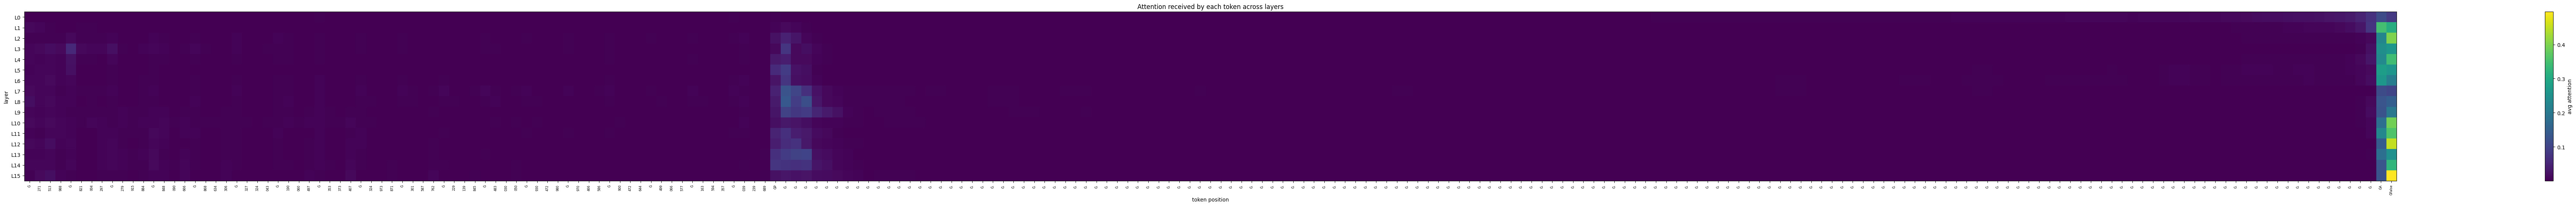

In [162]:
# AI GENERATED CELL
# ── heat-map across layers ─────────────────────────────────────────────
# NOTE that the extra eos tokens are from the dynamic padding, not a problem
import matplotlib.pyplot as plt

# one batch is enough
batch = next(iter(torch.utils.data.DataLoader(
    test_ds.select(range(6)),  # 1 example
    batch_size=1,
    collate_fn=custom_data_collator
)))

with torch.no_grad():
    out = model(**{k: v.to(model.device) for k, v in batch.items()},
                output_attentions=True, use_cache=False)

# build a (L, K) matrix: rows = layers, cols = token positions
layers = []
for attn in out.attentions:             # len = L
    heat = attn.mean(1)[0]              # (Q,K)
    ans_pos = (batch["labels"][0] != -100).nonzero(as_tuple=True)[0].item()
    seq_len = batch["attention_mask"][0].sum().item()
    heat = heat[ans_pos, 1:seq_len]     # drop BOS & pads
    if heat.sum() > 0:
        heat /= heat.sum()                  # re-normalise row
    layers.append(heat.float().cpu())   # keep on CPU, cast for matplotlib
mat = torch.stack(layers)               # (L, K)

toks = tok.convert_ids_to_tokens(
     batch["input_ids"][0][1:seq_len], skip_special_tokens=False
)

plt.figure(figsize=(80, mat.size(0) * .35))
plt.imshow(mat.numpy(), aspect='auto')
plt.colorbar(label='avg attention')
plt.yticks(range(mat.size(0)), [f'L{l}' for l in range(mat.size(0))])
plt.xticks(range(len(toks)), toks, rotation=90, fontsize=6)
plt.xlabel('token position')
plt.ylabel('layer')
plt.title('Attention received by each token across layers')
plt.tight_layout()
plt.show()


In [163]:
# ──────────────────────────────────────────────────────────────
# Attention hook
# ──────────────────────────────────────────────────────────────
def _record_attn(layer_idx, module, input, output):
    """Writes (B, H) into CURRENT_FILL (B, L, H)"""
    attention_probs = output[1]  # (B, H, Q, K)

    if cfg.filler_tok is None:
        # (1) Average attention uniformly across all query-key pairs:
        #     → shows general global attention strength per head.
        # fill = attention_probs.mean((-2, -1)) # (B,H)

        # (2) Avg each query's strongest attention weight across all queries:
        #     → bright if attn is sharp (queries strongly focus on single keys),
        #     → dark if attention is diffuse.
        # fill = attention_probs.max(-1).values.mean(-1) # (B,H)

        # (3) Attention at answer-token query ONLY:
        #     → precisely measures prediction-specific attention.
        ans_mask = (LABELS_THIS_BATCH != -100)[:, None, :, None]  # (B,1,Q,1)
        fill = (attention_probs * ans_mask).max(-1).values.mean(-2)  # sharpness
    else:
        filler_mask = torch.isin(
            TOKEN_IDS_THIS_BATCH.to(model.device),
            cfg.filler_id.to(model.device)
        )[:, None, None, :attention_probs.size(-1)]  # (B, 1, 1, K')
            # B matches
            # 1 broadcasts across all heads
            # 1 broadcasts across all query positions
            # K matches THIS pad, since we have dynamic padding, can't use K

        # Compute mean over query dimension
        # Mean attention **per filler token**, then avg over queries
        denom = filler_mask.sum(-1).clamp_min(1).float()  # (B,1,1,K)
        fill = (attention_probs*filler_mask).sum(-1).div(denom).mean(-1)  # (B,H)

    CURRENT_FILL[:, layer_idx, :] = fill.cpu()
    del attention_probs
    torch.cuda.empty_cache()

# Attach to every layer
def attach_attention_hooks(model):
    # return [
    #     block.self_attn.register_forward_hook(
    #         partial(_record_attn, layer_idx)
    #     ) for layer_idx, block in enumerate(model.model.layers)
    # ]
    # Trying this to avoid a memory leak; long story.
    return [
        block.self_attn.register_forward_hook(
            lambda m,i,o,idx=layer_idx: _record_attn(idx, m, i, o)
        ) for layer_idx, block in enumerate(model.model.layers)
    ]

L = model.config.num_hidden_layers
H = model.config.num_attention_heads
handles = attach_attention_hooks(model)


  0%|          | 0/25 [00:00<?, ?it/s]

Corpus filler rate: 67.033%


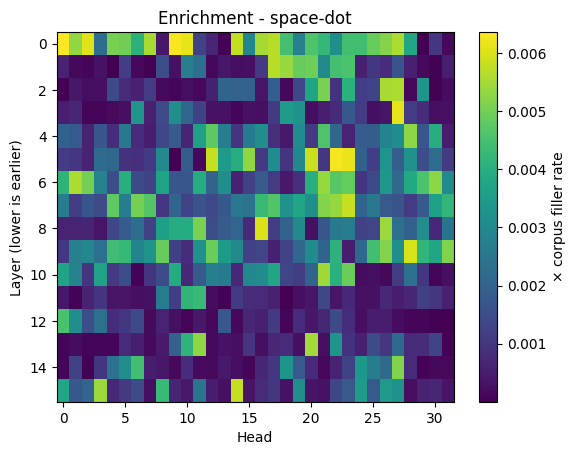

In [164]:
# ──────────────────────────────────────────────────────────────
# Attention logging and visualization
# ──────────────────────────────────────────────────────────────
def get_raw_attention(dataloader):
    global TOKEN_IDS_THIS_BATCH, CURRENT_FILL
    ATTN_BUCKET.clear()

    with torch.no_grad():
        for batch in tqdm(dataloader):
            TOKEN_IDS_THIS_BATCH = batch["input_ids"].to(model.device)  # (B, S)
            global LABELS_THIS_BATCH
            LABELS_THIS_BATCH = batch["labels"].to(model.device)

            B = TOKEN_IDS_THIS_BATCH.size(0)  # L and H are global
            CURRENT_FILL = torch.zeros(B, L, H)  # (B, L, H)
                # Remember CURRENT_FILL is filled by the hooks we set
            _ = model(
                **{k: v.to("cuda") for k, v in batch.items()},
                use_cache=False,
                output_attentions=True
            )
            ATTN_BUCKET.append(CURRENT_FILL.cpu())

    raw_attn = torch.cat(ATTN_BUCKET, dim=0)  # (N, L, H)

    # Memory leak fix:
    del ATTN_BUCKET[:]  # clear
    torch.cuda.empty_cache()

    return raw_attn

def calculate_enrichment(raw_attn):
    """Adjusts the attention for the percentage of filler tokens
    in the ds otherwise the attention mass is biased
    """
    # Calculate the filler rate
    n_fill, n_total = 0, 0
    for ex in test_ds:
        ids = ex["input_ids"]
        n_total += len(ids)
        n_fill += torch.isin(torch.tensor(ids, device=model.device),
                             cfg.filler_id.to(model.device)).sum().item()

    fill_rate = n_fill / n_total if n_total else 0.0
    print(f"Corpus filler rate: {fill_rate:.3%}")
        # THIS MIGHT BE WRONG FOR DIRECT?  BCAUSE THERES NO FILLER TO DILUTE  not sure what I'm looking for with direct

    # Calculate the enrichment
    prob_to_fill = raw_attn.mean(dim=0)  # (L, H)
    return prob_to_fill / max(fill_rate, 1e-9)

def plot_attention(mat, title=''):
    """Quick heat-map"""
    import matplotlib.pyplot as plt
    plt.imshow(mat.numpy(), aspect='auto')
    plt.xlabel("Head")
    plt.ylabel("Layer (lower is earlier)")
    plt.title(title)
    plt.colorbar(label="× corpus filler rate")
    plt.show()

# Get raw attention
ATTN_BUCKET = []
raw_attn = get_raw_attention(
    torch.utils.data.DataLoader(
        test_ds.shuffle().select(range(200)),
        batch_size=8,
        shuffle=False,
        collate_fn=custom_data_collator,
    )
)

# Convert to enrichment
    # I regret writing mean_attn because I don't even think I want these plots yet for direct runs.  Might be used later, I guess.  But for run = 'direct' I'm just moving to accuracy.
if cfg.filler_tok is not None:
    enr = calculate_enrichment(raw_attn)
    plot_attention(enr, f"Enrichment - {cfg.save_tag}")
    np.save(os.path.join(MODEL_DIR, "enrichment.npy"), enr.numpy())
else:
    mean_attn = raw_attn.mean(dim=0)
    plot_attention(mean_attn, f"Mean Attention - {cfg.save_tag}")
    np.save(os.path.join(MODEL_DIR, "mean_attn.npy"), mean_attn.numpy())


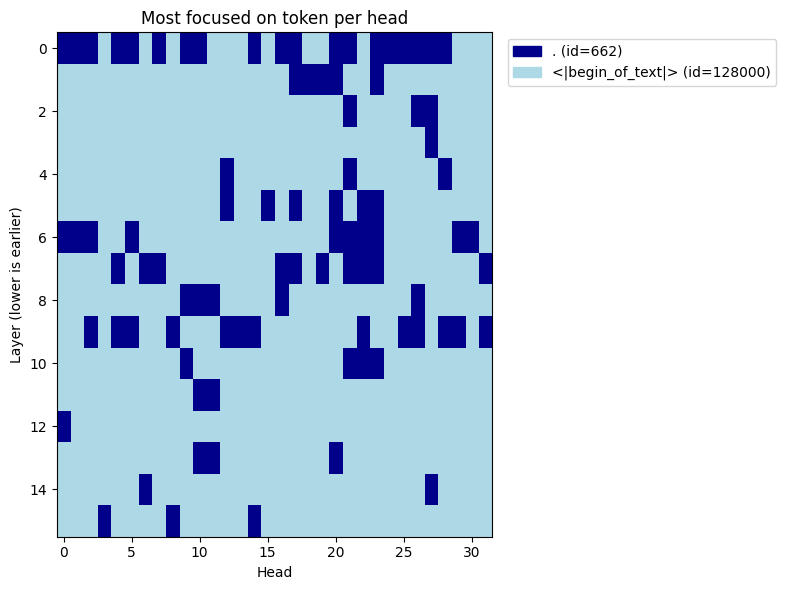

In [165]:
# AI GENERATED CELL
# Major token attended-to per head/layer categorical heat-map
# with fixed colours for special token-ids
import torch, numpy as np, matplotlib.pyplot as plt, matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm

# ── collect full attentions so raw_attn is 4-D (N,L,H,S) ───────────────
dl = torch.utils.data.DataLoader(
    test_ds.shuffle().select(range(200)),
    batch_size=8,
    shuffle=False,
    collate_fn=custom_data_collator,
)
attn_chunks, id_chunks = [], []
with torch.no_grad():
    for batch in dl:
        out = model(**{k: v.to(model.device) for k, v in batch.items()},
                     use_cache=False, output_attentions=True)
        attn_chunks.append(torch.stack(out.attentions, dim=1).mean(-2).cpu())  # (B,L,H,S)
        id_chunks.append(batch["input_ids"])
raw_attn = torch.cat(attn_chunks, 0)           # (N,L,H,S)
ids_all  = torch.cat(id_chunks,   0)           # (N,S)

N, L, H, S = raw_attn.shape
vocab = max(tok.vocab_size, ids_all.max().item() + 1)
attn_to_tok = torch.zeros(L, H, vocab, device=raw_attn.device)
for t in torch.unique(ids_all):
    mask = (ids_all == t).float()                                 # (N,S)
    attn_to_tok[:, :, t] = (raw_attn * mask[:, None, None, :]).sum(-1).mean(0)

maj_tok = attn_to_tok.argmax(-1).cpu()                            # (L,H)

# ── fixed colours for key token-ids ───────────────────────────────────
color_by_id = {
    128000: "#add8e6",                              # bos  → light-blue
    200:    "#bfff00",                              # space → light lime-green
    int(tok.filler_id): "#00008b",                  # filler → dark-blue
    getattr(tok, "eos_token_id", None): "#d3d3d3",  # eos  → light-grey
    getattr(tok, "cot_begin_id", None): "#ffa500",  # cot-begin → orange
    getattr(tok, "cot_end_id",   None): "#ff69b4",  # cot-end   → hot-pink
}
color_by_id = {k: v for k, v in color_by_id.items() if k is not None}

# Re-index token-ids to 0..K-1 for palette
cat_ids = torch.unique(maj_tok).tolist()
idx_map = {t: i for i, t in enumerate(cat_ids)}
maj_idx = np.vectorize(idx_map.get)(maj_tok.numpy())              # (L,H)

# Build colour list: fixed first, fall-back to tab20 for the rest
base_palette = iter(plt.cm.tab20(np.linspace(0, 1, 20)))
colors = [
    color_by_id.get(t, next(base_palette))
    for t in cat_ids
]

cmap = ListedColormap(colors)
norm = BoundaryNorm(np.arange(len(cat_ids) + 1) - 0.5, cmap.N)

# ── plot ──────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 6))
plt.imshow(maj_idx, cmap=cmap, norm=norm, aspect='auto')
plt.xlabel("Head")
plt.ylabel("Layer (lower is earlier)")
plt.title("Most focused on token per head")
labels = [tok.decode([t]) if hasattr(tok, "decode") else str(t) for t in cat_ids]
patches = [mpatches.Patch(color=colors[i], label=f"{labels[i]} (id={cat_ids[i]})")
           for i in range(len(cat_ids))]
plt.legend(handles=patches, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [15]:
# ──────────────────────────────────────────────────────────────
# Accuracy Eval
# ──────────────────────────────────────────────────────────────
# Remove these if they're still on
for handle in handles:
    handle.remove()

def accuracy(model, testset) -> float:
    """Evaluates model accuracy on test set"""
    # Iterate over test set
    invalid, correct = Counter(), 0
    with torch.no_grad():
        for ex in tqdm(testset, leave=False):
            # Forward the input to get an output
            ids = torch.tensor(
                ex["input_ids"], device=model.device
            ).unsqueeze(0)
            mask = torch.ones_like(ids)

            # Drop the filler tokens
            cut = (ids[0] == tok.cot_begin_id).nonzero(as_tuple=True)[0] + 1
            exp_id = ids[0, -1].item()  # Grab answer
            ids, mask = ids[:, :cut], mask[:, :cut]  # keep prompt and cot_begin

            out = model.generate(
                input_ids=ids,
                attention_mask=mask,
                max_new_tokens=1,
                do_sample=False,
                temperature=None,
                top_p=None,  # Trying these to None because warnings?
            )

            # Check answer
            pred_id = out[0, -1].item()

            # ─── DEBUG ───
            print(
                f"cut={cut}, "
                f"prompt_tail={tok.decode(ids[0,-3:].tolist())!r}, "
                f"expected={exp_id}→{tok.decode([exp_id])!r}, "
                f"predicted={pred_id}→{tok.decode([pred_id])!r}"
            )
            break

            if pred_id == exp_id:
                correct += 1
            elif pred_id not in [tok.true_id, tok.false_id]:
                print(pred_id)
                break
                invalid[pred_id] += 1

    accuracy = correct / len(testset)
    return accuracy, invalid

# this is off now that I don't have puncts/no puncts since that would be handled by aggregating several runs of data, not something we do all at once necessarily?  I guess we can do it all at once after all the models are trained, but it seems useful to have some sort of utility function that works as we go so we can tune the runs.
acc_puncts, invalid_puncts = accuracy(
    model, test_ds.shuffle().select(range(100))
)

print(f"Invalid count: {sum(invalid_puncts)}")
print(f"Accuracy: {acc_puncts:.3f}")


  0%|          | 0/100 [00:00<?, ?it/s]

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


cut=tensor([74], device='cuda:0'), prompt_tail='266308 P', expected=3082→' True', predicted=5726→'RA'
Invalid count: 0
Accuracy: 0.000


# Debug Cells

In [ ]:
print(tok.convert_ids_to_tokens(220, skip_special_tokens=True))

In [ ]:
# AI GENERATED DEBUG CELL
from itertools import islice

N_EXAMPLES = 2          # how many rows of the HF dataset to inspect
MAX_COLS   = 120        # crop very long prompts for readability

for ex_idx in range(N_EXAMPLES):
    ids   = train_ds[ex_idx]['input_ids']
    lbls  = train_ds[ex_idx]['labels']
    toks  = tok.convert_ids_to_tokens(ids, skip_special_tokens=False)

    print(f"\n── Example {ex_idx} ──")
    print("pos | token                    | id         | label_id")
    print("----+---------------------------+------------+----------")
    for pos, (tok_str, tok_id, lab_id) in enumerate(zip(toks, ids, lbls)):
        print(f"{pos:3d} | {tok_str:<25.25} | {tok_id:<10d} | {lab_id}")
        if lab_id != -100 and lab_id != tok_id:
            raise ValueError(
                f"Label/input mismatch at pos {pos}: "
                f"input={tok_id}, label={lab_id}"
            )

print("\n✓ All inspected examples have self-consistent masks.")


In [ ]:
# AI GENERATED CELL
import torch
from itertools import islice

N_TO_SHOW = 10           # how many examples to dump

def show_eval_io(model, ds, n=N_TO_SHOW):
    """
    Prints, for n examples:
      • input token, input id
      • predicted token, predicted id
      • expected (last prompt token) token & id
    """
    for ex_num, ex in enumerate(islice(ds.shuffle(seed=0), n)):
        ids  = torch.tensor(ex["input_ids"], device=model.device).unsqueeze(0)
        mask = torch.ones_like(ids)

        # === generate one token (same args as in your accuracy()) ============
        out = model.generate(
            input_ids       = ids,
            attention_mask  = mask,
            max_new_tokens  = 1,
            do_sample       = False,
            temperature     = None,
            top_p           = None,
        )

        pred_id  = out[0, -1].item()
        exp_id   = ids[0, -1].item()

        pred_tok = tok.convert_ids_to_tokens([pred_id],  skip_special_tokens=False)[0]
        exp_tok  = tok.convert_ids_to_tokens([exp_id],   skip_special_tokens=False)[0]

        # === pretty print ====================================================
        print(f"\n━━ Example {ex_num} ━━")
        print("pos │ token                    │ id")
        print("───┼───────────────────────────┼────────")
        for pos, tok_id in enumerate(ids[0].tolist()):
            tok_str = tok.convert_ids_to_tokens([tok_id], skip_special_tokens=False)[0]
            print(f"{pos:3d} │ {tok_str:<25.25} │ {tok_id}")

        print("───┴───────────────────────────┴────────")
        print(f"Expected (last prompt token): {exp_tok!r:25} id={exp_id}")
        print(f"Predicted by model          : {pred_tok!r:25} id={pred_id}")
        verdict = "✓ MATCH" if pred_id == exp_id else "✗ MISMATCH"
        print("Result:", verdict)

# call it
show_eval_io(model, test_ds, n=N_TO_SHOW)
